# 🎓 Student Academic Performance Prediction

## 📌 Introduction

This project focuses on predicting students' academic performance using Machine Learning.

The dataset contains information about students' habits and lifestyle, such as study time, sleep, attendance, and other factors that may be related to academic performance.

The main goal of this project is to build a Machine Learning model that can predict a student's **exam score** based on their habits and other available features.

The project follows an end-to-end Machine Learning workflow, including:

- Data Understanding
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Comparison
- Model Evaluation
- Hyperparameter Tuning
- Model Interpretation

## 🎯 Problem Statement

Can we use students' habits and lifestyle information to predict their exam scores?

The target variable is the **exam score**, making this a **regression problem** because the model predicts a continuous numerical value.

## 📚 Import Libraries

In this section, we import the Python libraries required for data manipulation, numerical analysis, and data visualization.

In [97]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

## 📂 Load Dataset

In this section, we load the Student Habits vs Academic Performance dataset into a Pandas DataFrame for further analysis and Machine Learning.

In [98]:
df= pd.read_csv('student_habits_performance.csv')

## 🔍 Data Understanding

In this section, we explore the dataset to understand its structure, features, data types, and basic statistical information.

We will:

- Check the number of rows and columns
- Inspect the first few rows
- Examine data types
- Check for missing values
- Check for duplicate records
- Review descriptive statistics

In [99]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [101]:
df.shape

(1000, 16)

In [102]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [103]:
df.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64

In [104]:
df[df['parental_education_level'].isnull()]

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
10,S1010,19,Female,4.6,3.7,0.8,No,77.6,5.8,Fair,1,NaN,Good,3,No,63.3
33,S1033,18,Female,4.0,0.9,1.1,No,99.5,5.8,Poor,2,NaN,Average,5,No,70.7
47,S1047,23,Female,2.5,2.9,2.7,No,83.5,7.0,Good,4,NaN,Good,8,Yes,59.7
74,S1074,21,Female,2.3,1.0,0.4,No,100.0,6.4,Fair,6,NaN,Good,1,No,66.9
93,S1093,22,Male,4.1,2.5,3.0,No,85.1,5.8,Good,4,NaN,Good,5,No,70.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
921,S1921,23,Female,4.4,2.7,1.0,No,79.8,6.1,Fair,6,NaN,Average,3,No,85.4
925,S1925,19,Other,1.7,2.9,1.6,Yes,97.3,8.7,Good,1,NaN,Good,7,No,53.6
939,S1939,18,Female,4.7,3.2,1.9,No,75.2,5.4,Good,3,NaN,Good,6,No,71.0
945,S1945,23,Male,6.0,2.9,2.1,Yes,98.9,6.4,Poor,0,NaN,Average,7,No,100.0


In [105]:
df.duplicated().sum()

np.int64(0)

## 🧹 Data Cleaning

In this section, we clean the dataset and prepare it for analysis.

We will:

* Handle missing values
* Check and remove duplicate records if any
* Fix data types if needed
* Check for invalid values


In [106]:
df['parental_education_level']= df['parental_education_level'].fillna('UnKnown')

In [107]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [108]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64

## 📊 Exploratory Data Analysis (EDA)

In this section, we explore the dataset and look for patterns and relationships between students' habits and their exam scores.

We will focus on:

* Exam score distribution
* Relationships between habits and exam scores
* Differences in exam scores across categories
* Correlations between numerical features


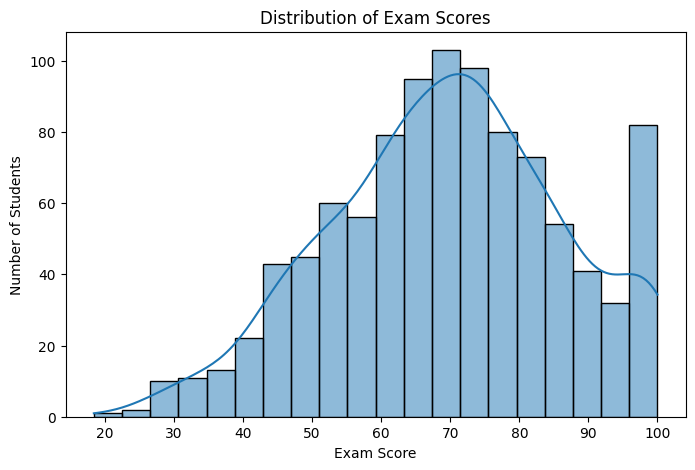

In [109]:
plt.figure(figsize=(8,5))
sns.histplot(df['exam_score'], bins=20, kde=True)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')
plt.show()

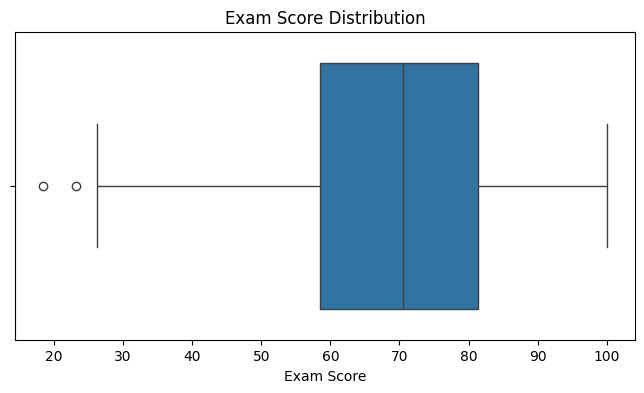

In [110]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['exam_score'])
plt.title('Exam Score Distribution')
plt.xlabel('Exam Score')
plt.show()

In [111]:
Q1 = df['exam_score'].quantile(.25)
Q3 = df['exam_score'].quantile(.75)


IQR = Q3 - Q1

Lower_bound = Q1 - (1.5 * IQR)
Higher_bound = Q3 + (1.5 * IQR)

print('Lower_bound:',Lower_bound)
print('Higher_bound:',Higher_bound)

Lower_bound: 24.199999999999996
Higher_bound: 115.60000000000001


In [112]:
Outliers = df[ (df['exam_score'] < Lower_bound) | (df['exam_score'] > Higher_bound)] 
Outliers

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
265,S1265,18,Female,0.6,3.1,3.0,No,79.9,5.2,Good,1,Bachelor,Good,4,No,18.4
327,S1327,23,Male,0.9,2.4,2.5,No,89.2,6.9,Fair,0,High School,Poor,1,No,23.1


In [113]:
df['exam_score'].describe()

count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64

### Study Hours vs Exam Score

This plot shows the relationship between students' study hours per day and their exam scores.

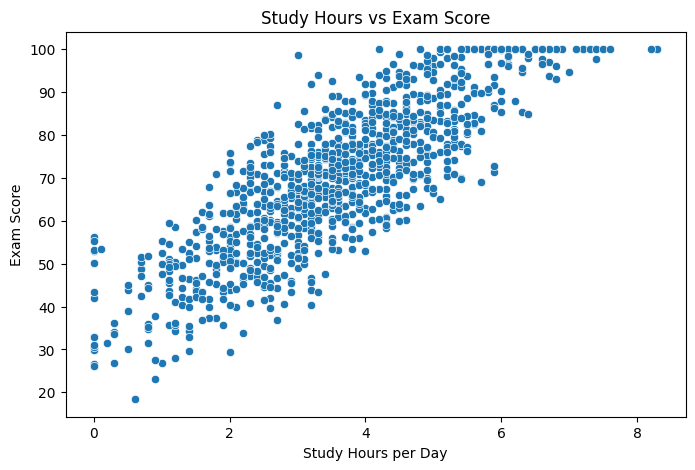

In [114]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='study_hours_per_day', y='exam_score')
plt.title('Study Hours vs Exam Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Exam Score')
plt.show()

### Insight

The scatter plot shows a clear positive relationship between study hours and exam scores.

Students who spend more hours studying per day generally tend to have higher exam scores. This suggests that study hours may be an important feature for predicting academic performance.

### Sleep Hours vs Exam Score


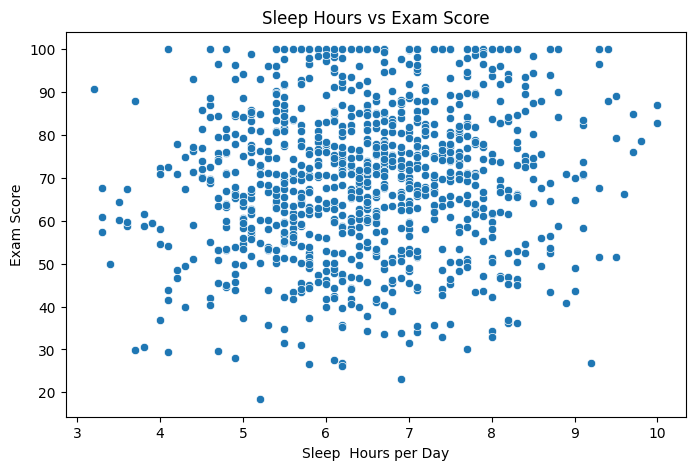

In [115]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='sleep_hours', y='exam_score')
plt.title('Sleep Hours vs Exam Score')
plt.xlabel('Sleep  Hours per Day')
plt.ylabel('Exam Score')
plt.show()

The scatter plot shows a weak relationship between sleep hours and exam scores.

Exam scores are widely distributed across different sleep durations, with no strong or clear pattern visible. Therefore, sleep hours may have a limited direct relationship with exam scores in this dataset.

### Attendance Percentage vs Exam Score


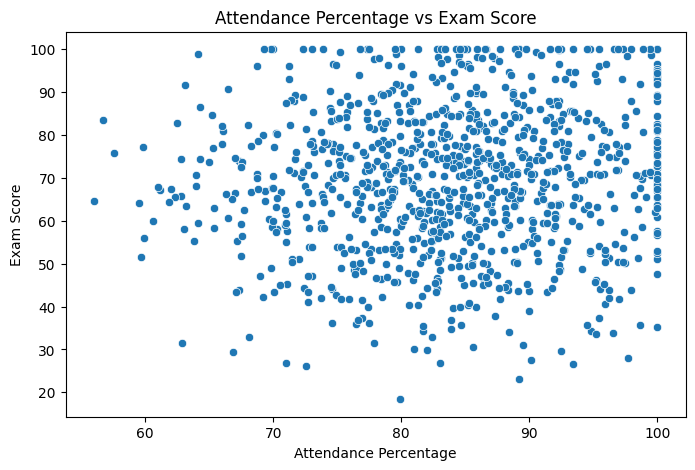

In [116]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='attendance_percentage', y='exam_score')
plt.title('Attendance Percentage vs Exam Score')
plt.xlabel('Attendance Percentage')
plt.ylabel('Exam Score')
plt.show()

The scatter plot shows a weak positive relationship between attendance percentage and exam scores.

Higher attendance percentages are generally associated with somewhat higher exam scores, but the points are widely scattered. This indicates that attendance alone does not strongly determine exam performance.

### Social Media Hours vs Exam Score


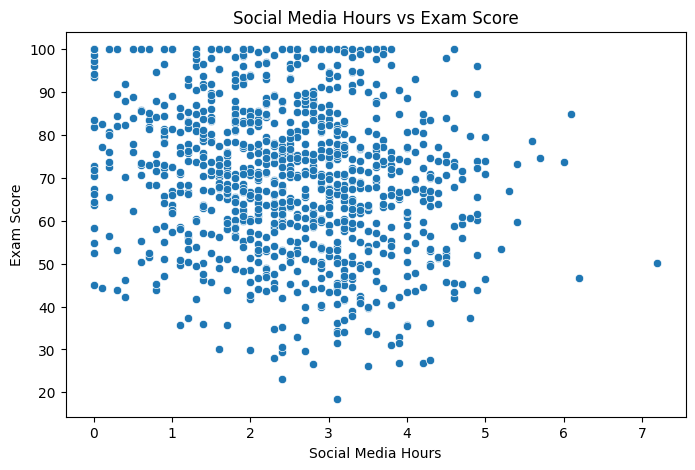

In [117]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='social_media_hours', y='exam_score')
plt.title('Social Media Hours vs Exam Score')
plt.xlabel('Social Media Hours')
plt.ylabel('Exam Score')
plt.show()

The scatter plot shows a weak negative relationship between social media hours and exam scores.

Students with higher social media usage tend to have slightly lower exam scores on average. However, the points are widely scattered, indicating that the relationship is not strong.

### Netflix Hours vs Exam Score


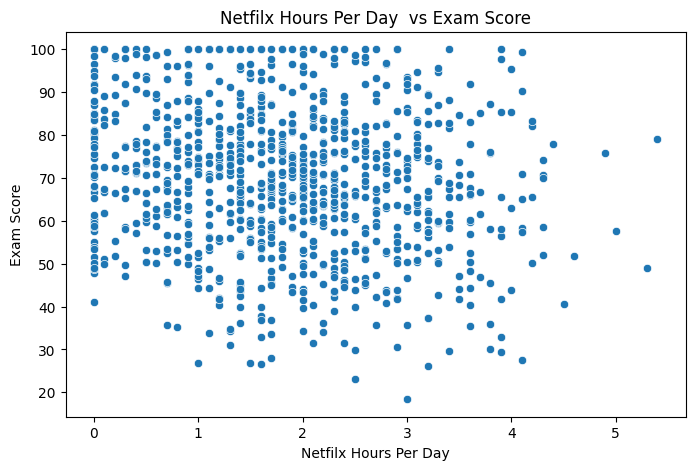

In [118]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='netflix_hours', y='exam_score')
plt.title('Netfilx Hours Per Day  vs Exam Score')
plt.xlabel('Netfilx Hours Per Day')
plt.ylabel('Exam Score')
plt.show()

The scatter plot shows a very weak relationship between Netflix hours and exam scores.

Exam scores are widely distributed across different levels of Netflix usage, with no strong or clear pattern visible in the data.    

### Exercise Frequency vs Exam Score

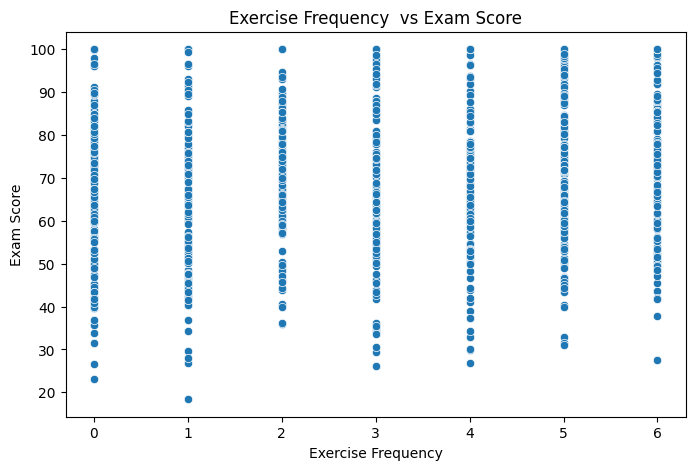

In [119]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='exercise_frequency', y='exam_score')
plt.title('Exercise Frequency  vs Exam Score')
plt.xlabel('Exercise Frequency')
plt.ylabel('Exam Score')
plt.show()

The scatter plot does not show a clear relationship between exercise frequency and exam scores.

Exam scores vary widely across all exercise frequency levels. This suggests that exercise frequency alone does not have a strong visible relationship with exam performance in this dataset.

## 📈 Correlation Analysis

In this section, we analyze the correlation between numerical features and exam scores.

Correlation helps us understand the strength and direction of linear relationships between numerical variables.

We will use a correlation matrix and heatmap to identify features that have stronger relationships with the exam score.

In [120]:
corr = df.corr(numeric_only=True)
corr['exam_score'].sort_values(ascending=False)

exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64

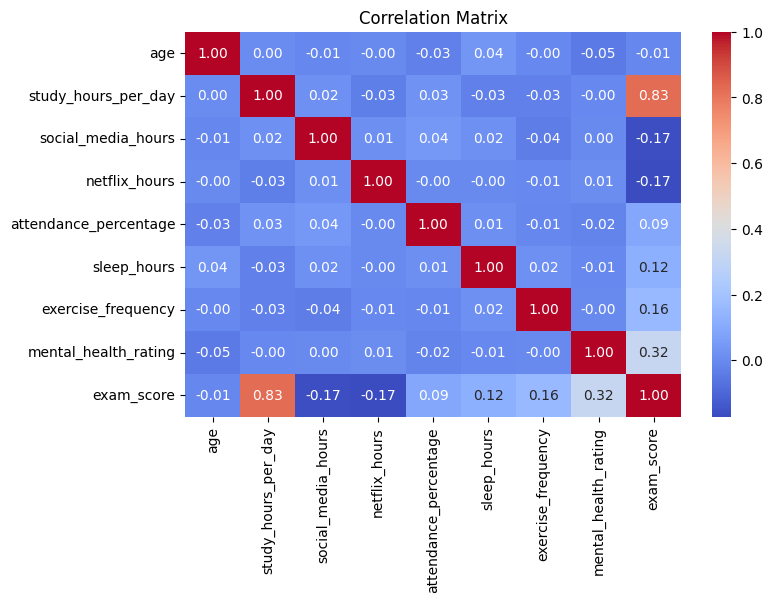

In [121]:
plt.figure(figsize=(8,5))
sns.heatmap(corr, annot=True , cmap='coolwarm',fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

### Correlation Analysis Insights

The correlation analysis shows that `study_hours_per_day` has the strongest positive correlation with exam score, with a correlation coefficient of **0.83**.

`mental_health_rating` shows a moderate positive correlation with exam score (**0.32**), while `exercise_frequency`, `sleep_hours`, and `attendance_percentage` show weak positive correlations.

`social_media_hours` and `netflix_hours` have weak negative correlations with exam score, while `age` shows almost no linear correlation.

Overall, `study_hours_per_day` has the strongest linear relationship with exam score among the numerical features in this dataset.

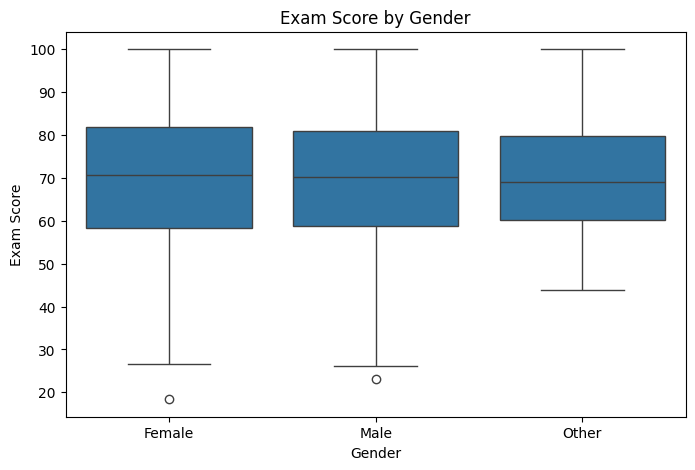

In [122]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='gender', y='exam_score')

plt.title('Exam Score by Gender')
plt.xlabel('Gender')
plt.ylabel('Exam Score')
plt.show()

### Gender vs Exam Score

The boxplot shows that exam score distributions are similar across the different gender categories.

The median exam scores are close to each other, with similar overall score ranges. This suggests that gender does not show a strong visible relationship with exam scores in this dataset.

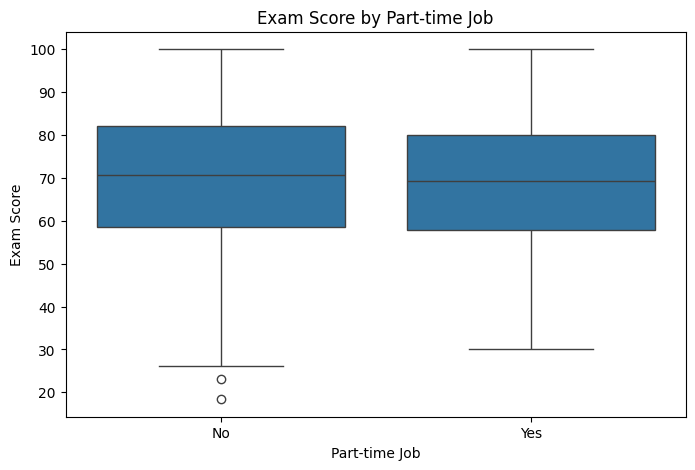

In [123]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='part_time_job', y='exam_score')

plt.title('Exam Score by Part-time Job')
plt.xlabel('Part-time Job')
plt.ylabel('Exam Score')
plt.show()

### Part-time Job vs Exam Score

The boxplot shows similar exam score distributions for students with and without a part-time job.

The median exam scores are close, although students without a part-time job show a slightly wider range of scores. Overall, there is no strong visible difference in exam scores between the two groups.

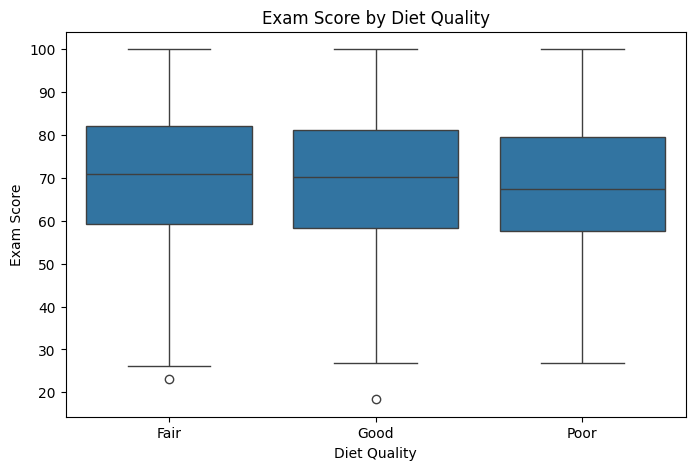

In [124]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='diet_quality', y='exam_score')

plt.title('Exam Score by Diet Quality')
plt.xlabel('Diet Quality')
plt.ylabel('Exam Score')
plt.show()

### Diet Quality vs Exam Score

The boxplot shows some differences in exam scores across diet quality categories.

Students with a Fair or Good diet have slightly higher median exam scores than students with a Poor diet. However, the distributions overlap considerably, so the difference is relatively small.

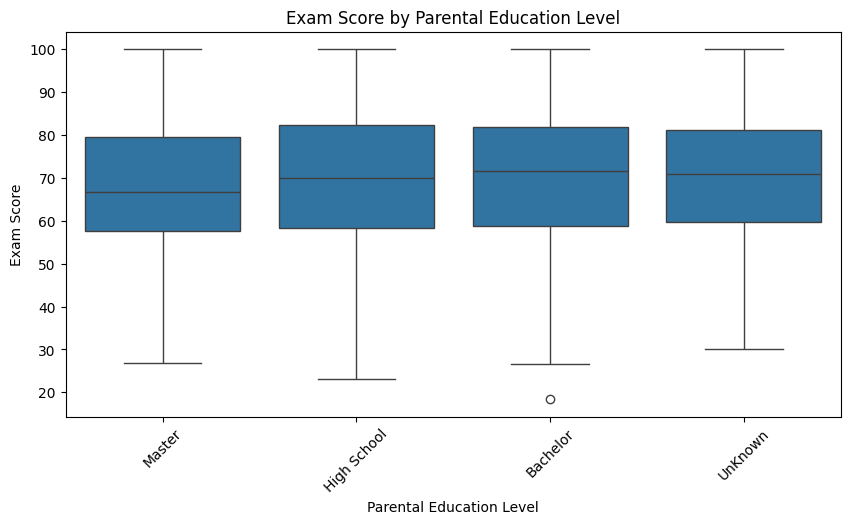

In [125]:
plt.figure(figsize=(10,5))

sns.boxplot(data=df, x='parental_education_level', y='exam_score')

plt.title('Exam Score by Parental Education Level')
plt.xlabel('Parental Education Level')
plt.ylabel('Exam Score')
plt.xticks(rotation=45)
plt.show()

### Parental Education Level vs Exam Score

The boxplot shows some variation in exam scores across different parental education levels.

Students with a Bachelor's degree as their parental education level have a slightly higher median exam score, while the other categories have relatively similar distributions. Overall, the differences are moderate and the score distributions overlap considerably.

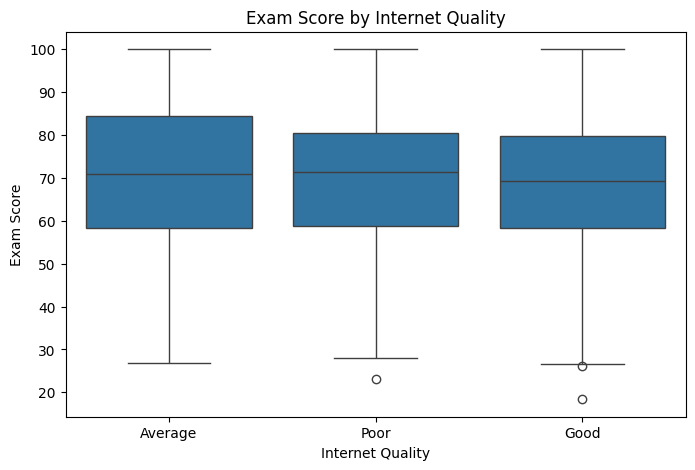

In [126]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='internet_quality', y='exam_score')

plt.title('Exam Score by Internet Quality')
plt.xlabel('Internet Quality')
plt.ylabel('Exam Score')
plt.show()

### Internet Quality vs Exam Score

The boxplot shows similar exam score distributions across the different internet quality categories.

The median scores are close to each other, and the distributions overlap considerably. This suggests that internet quality does not show a strong visible relationship with exam scores in this dataset.

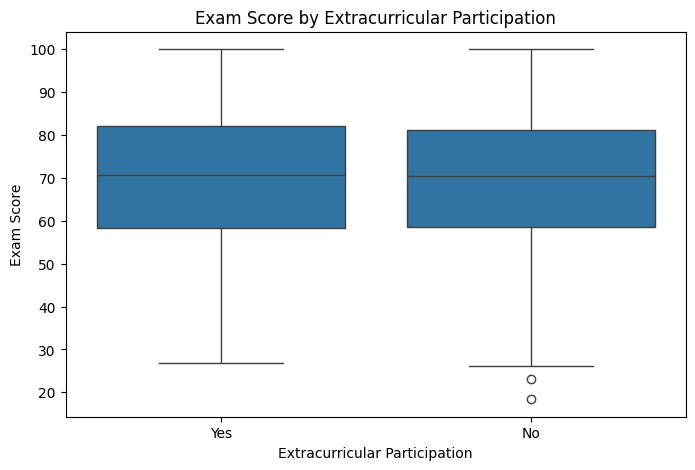

In [127]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x='extracurricular_participation', y='exam_score')

plt.title('Exam Score by Extracurricular Participation')
plt.xlabel('Extracurricular Participation')
plt.ylabel('Exam Score')
plt.show()

### Extracurricular Participation vs Exam Score

The boxplot shows similar exam score distributions for students who participate in extracurricular activities and those who do not.

The median exam scores are nearly the same, and the score distributions overlap considerably. This suggests that extracurricular participation does not show a strong visible relationship with exam scores in this dataset.

## 📌 EDA Summary

The exploratory analysis revealed several patterns in the dataset.

- Study hours show the strongest positive relationship with exam scores.
- Mental health rating shows a moderate positive correlation with exam scores.
- Social media and Netflix usage show weak negative relationships with exam scores.
- Most categorical features show relatively similar exam score distributions across their categories.
- Several numerical and categorical features show weak or moderate relationships, suggesting that exam performance may depend on multiple factors.

These findings will help guide the feature selection and preprocessing steps before building the Machine Learning models.

## ⚙️ Feature Engineering

In this section, we prepare the dataset for Machine Learning.

We will:

- Remove the `student_id` column because it is only an identifier and does not provide useful information for prediction.
- Convert categorical features into numerical features using one-hot encoding.
- Separate the features from the target variable (`exam_score`).

In [128]:
df = df.drop('student_id',axis=1)

In [129]:
df=pd.get_dummies(df,drop_first=True,dtype=int)

In [130]:
df.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,parental_education_level_UnKnown,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,0,0,0,0,0,0,1,0,0,0,1
1,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,0,0,0,1,0,1,0,0,0,0,0
2,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,1,0,0,0,1,1,0,0,0,1,0
3,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,0,0,0,0,1,0,1,0,1,0,1
4,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,0,0,0,0,0,0,1,0,1,0,0


In [131]:
X = df.drop('exam_score', axis=1)
y = df['exam_score']

## ✂️ Train-Test Split

In this section, we split the dataset into training and testing sets.

- The **training set** will be used to train the Machine Learning models.
- The **testing set** will be used to evaluate how well the models perform on unseen data.

We will use **80% of the data for training** and **20% for testing**.

In [132]:
from sklearn.model_selection import train_test_split

In [133]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [134]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

## 6. Preprocessing

* Used `StandardScaler` to scale the numerical features.
* Kept dummy variables as `0/1`.
* Fitted the scaler on the training data and used it to transform both training and test data.
* The target variable `exam_score` was not scaled.


In [135]:
from sklearn.preprocessing import StandardScaler

numerical_features = [
    'age',
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating'
]

scaler = StandardScaler()

scaled_X_train = X_train.copy()
scaled_X_test = X_test.copy()

scaled_X_train[numerical_features] = scaler.fit_transform(
    X_train[numerical_features]
)

scaled_X_test[numerical_features] = scaler.transform(
    X_test[numerical_features]
)

In [136]:
scaled_X_train.head()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,parental_education_level_UnKnown,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
29,-0.210232,-1.049785,0.612601,1.813009,-0.176040,0.191900,1.456276,1.592488,0,0,1,0,1,1,0,0,0,1,1
535,0.658944,1.915186,1.469385,-0.293810,0.482898,-0.297797,-1.524587,0.188642,0,0,1,0,0,1,0,0,1,0,0
695,-0.210232,-0.712857,-0.501219,-0.202209,0.993043,0.436749,0.462655,0.890565,0,0,0,1,0,0,0,0,1,0,0
557,0.658944,0.163158,0.955315,2.271013,1.673237,0.681598,-1.027777,0.539603,1,0,0,0,1,0,0,0,0,1,1
836,-0.644820,-0.038999,0.269887,-1.667822,0.822995,-2.174971,0.959465,-0.162320,1,0,0,0,0,0,0,1,0,1,1


## 7. Model Training

Several regression models will be trained to predict students' exam scores.

The preprocessed training data will be used to train the models, and their performance will be compared in the next stage.


## 7.1 Linear Regression

Linear Regression was used as the first baseline model for predicting `exam_score`.

* Trained the model using the training data.
* Generated predictions on the test data.
* Evaluated the model using **MAE**, **RMSE**, and **R²**.

Linear Regression provides a simple baseline that can be used to compare its performance with more advanced regression models.


In [137]:
from sklearn.linear_model import LinearRegression

In [138]:
linear=LinearRegression()

linear.fit(scaled_X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [139]:
y_pred = linear.predict(scaled_X_test)

In [140]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [161]:
lr_mae= mean_absolute_error(y_test,y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test,y_pred))
lr_r2= r2_score(y_test,y_pred)

In [162]:
print('MAE:',lr_mae)
print('RMSE:',lr_rmse)
print('R2:',lr_r2)

MAE: 4.189311054627599
RMSE: 5.1455064332842095
R2: 0.8967502640380202


## 7.2 Ridge Regression

* Created a Ridge Regression model.
* Trained the model on the training data.
* Made predictions on the test data.
* Evaluated the model using MAE, RMSE, and R².


In [143]:
from sklearn.linear_model import Ridge

In [144]:
ridge=Ridge()
ridge.fit(scaled_X_train,y_train)


,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [145]:
ridge_pred = ridge.predict(scaled_X_test)

In [163]:
ridge_mae= mean_absolute_error(y_test,ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test,ridge_pred))
ridge_r2= r2_score(y_test,ridge_pred)

print('MAE:',ridge_mae)
print('RMSE:',ridge_rmse)
print('R2:',ridge_r2)

MAE: 4.189115100946808
RMSE: 5.145985169479472
R2: 0.8967310505025425


## 7.3 LASSO

* Created a Ridge Regression model.
* Trained the model on the training data.
* Made predictions on the test data.
* Evaluated the model using MAE, RMSE, and R².


In [147]:
from sklearn.linear_model import Lasso

In [148]:
lasso= Lasso()
lasso.fit(scaled_X_train,y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [149]:
lasso_pred = lasso.predict(scaled_X_test)

In [164]:
lasso_mae= mean_absolute_error(y_test,lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test,lasso_pred))
lasso_r2= r2_score(y_test,lasso_pred)

print('MAE:',lasso_mae)
print('RMSE:',lasso_rmse)
print('R2:',lasso_r2)

MAE: 4.632550072116559
RMSE: 5.768339367886458
R2: 0.870241951548631


## 7.4 Decision Tree Regressor 

* Created a Ridge Regression model.
* Trained the model on the training data.
* Made predictions on the test data.
* Evaluated the model using MAE, RMSE, and R².

In [152]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor(random_state=42)
dt.fit(scaled_X_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [153]:
dt_pred= dt.predict(scaled_X_test)

In [165]:
dt_mae= mean_absolute_error(y_test,dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test,dt_pred))
dt_r2= r2_score(y_test,dt_pred)

print('MAE:',dt_mae)
print('RMSE:',dt_rmse)
print('R2:',dt_r2)

MAE: 7.4270000000000005
RMSE: 9.524263751072837
R2: 0.646250751513783


## 7.5 Random Forest Regressor 

* Created a Ridge Regression model.
* Trained the model on the training data.
* Made predictions on the test data.
* Evaluated the model using MAE, RMSE, and R².

In [156]:
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(random_state=42)
rf.fit(scaled_X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [157]:
rf_pred= rf.predict(scaled_X_test)

In [166]:
rf_mae= mean_absolute_error(y_test,rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))
rf_r2= r2_score(y_test,rf_pred)

print('MAE:',rf_mae)
print('RMSE:',rf_rmse)
print('R2:',rf_r2)

MAE: 4.941585000000003
RMSE: 6.2053957218698015
R2: 0.849833982704521


## 8. Model Comparison

* Compared the performance of all trained regression models.
* Used **MAE**, **RMSE**, and **R²** for comparison.
* Lower MAE and RMSE indicate better performance.
* Higher R² indicates better performance.


In [167]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'MAE': [
        lr_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae
    ],
    'RMSE': [
        lr_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse
    ],
    'R²': [
        lr_r2,
        ridge_r2,
        lasso_r2,
        dt_r2,
        rf_r2
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,4.189311,5.145506,0.896750
1,Ridge Regression,4.189115,5.145985,0.896731
2,Lasso Regression,4.632550,5.768339,0.870242
3,Decision Tree,7.427000,9.524264,0.646251
4,Random Forest,4.941585,6.205396,0.849834


## 9. Hyperparameter Tuning

Hyperparameter tuning was used to find better settings for the machine learning models and improve their performance.


In [168]:
from sklearn.model_selection import GridSearchCV

In [170]:
param_grid= { 
    'alpha':[.01,.1,1,10,100]
}

In [171]:
ridge= Ridge()

In [172]:
grid_search = GridSearchCV(
    ridge,
    param_grid,
    cv=5,
    scoring='r2'
)

In [173]:
grid_search.fit(scaled_X_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are also d

In [174]:
grid_search.best_params_

{'alpha': 1}

In [176]:
best_grid=grid_search.best_estimator_

In [177]:
best_grid_pred = best_grid.predict(scaled_X_test)

In [180]:
g_mae = mean_absolute_error(y_test, best_grid_pred)
g_rmse = np.sqrt(mean_squared_error(y_test, best_grid_pred))
g_r2 = r2_score(y_test, best_grid_pred)

In [181]:
print('MAE:',g_mae)
print('RMSE:',g_rmse)
print('R2:',g_r2)

MAE: 4.189115100946808
RMSE: 5.145985169479472
R2: 0.8967310505025425


In [188]:
param_grid = {
    'n_estimators':[100,200],
    'max_depth': [None,10 ,20 ],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

In [189]:
rf = RandomForestRegressor(random_state=42)

In [190]:
rf_grid = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=1
)

In [191]:
rf_grid.fit(scaled_X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [192]:
print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [193]:
best_rf = rf_grid.best_estimator_

In [194]:
rf_tuned_pred = best_rf.predict(scaled_X_test)

In [195]:
r_mae = mean_absolute_error(y_test, rf_tuned_pred)
r_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))
r_r2 = r2_score(y_test, rf_tuned_pred)

print('MAE:', r_mae)
print('RMSE:', r_rmse)
print('R2:', r_r2)

MAE: 4.939613928571429
RMSE: 6.168266814343689
R2: 0.8516255912982135


In [196]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Tuned Ridge Regression',
        'Lasso Regression',
        'Decision Tree',
        'Random Forest',
        'Tuned Random Forest'
    ],
    'MAE': [
        lr_mae,
        ridge_mae,
        g_mae,
        lasso_mae,
        dt_mae,
        rf_mae,
        r_mae
    ],
    'RMSE': [
        lr_rmse,
        ridge_rmse,
        g_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse,
        r_rmse
    ],
    'R²': [
        lr_r2,
        ridge_r2,
        g_r2,
        lasso_r2,
        dt_r2,
        rf_r2,
        r_r2
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,4.189311,5.145506,0.896750
1,Ridge Regression,4.189115,5.145985,0.896731
2,Tuned Ridge Regression,4.189115,5.145985,0.896731
3,Lasso Regression,4.632550,5.768339,0.870242
4,Decision Tree,7.427000,9.524264,0.646251
5,Random Forest,4.941585,6.205396,0.849834
6,Tuned Random Forest,4.939614,6.168267,0.851626


## 10. Final Evaluation

The final model was evaluated on the test data using MAE, RMSE, and R².


In [197]:
final_pred =linear.predict(scaled_X_test)

In [198]:
final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, final_pred))
final_r2 = r2_score(y_test, final_pred)

print('Final MAE:', final_mae)
print('Final RMSE:', final_rmse)
print('Final R²:', final_r2)

Final MAE: 4.189311054627599
Final RMSE: 5.1455064332842095
Final R²: 0.8967502640380202


## 11. Feature Importance / Interpretation

Feature importance was analyzed using the coefficients of the final Linear Regression model.

* Positive coefficients indicate that higher values of a feature are associated with higher predicted exam scores.
* Negative coefficients indicate that higher values of a feature are associated with lower predicted exam scores.
* Larger absolute coefficient values indicate a stronger linear influence on the model's predictions.
* The coefficients were used to understand which features have the strongest influence on predicted exam scores.


In [200]:
feature_names = X_train.columns

coefficients = linear.coef_

In [201]:
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

feature_importance

,Feature,Coefficient
0,age,0.120528
1,study_hours_per_day,14.144736
2,social_media_hours,-3.133815
3,netflix_hours,-2.534400
4,attendance_percentage,1.359685
5,sleep_hours,2.421586
6,exercise_frequency,2.656236
7,mental_health_rating,5.564302
8,gender_Male,0.134296
9,gender_Other,0.810709


In [202]:
feature_importance['Absolute_Coefficient'] = (
    feature_importance['Coefficient'].abs()
)

feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute_Coefficient
1,study_hours_per_day,14.144736,14.144736
7,mental_health_rating,5.564302,5.564302
2,social_media_hours,-3.133815,3.133815
6,exercise_frequency,2.656236,2.656236
3,netflix_hours,-2.534400,2.534400
5,sleep_hours,2.421586,2.421586
4,attendance_percentage,1.359685,1.359685
11,diet_quality_Good,-0.958356,0.958356
15,parental_education_level_UnKnown,-0.839483,0.839483
9,gender_Other,0.810709,0.810709


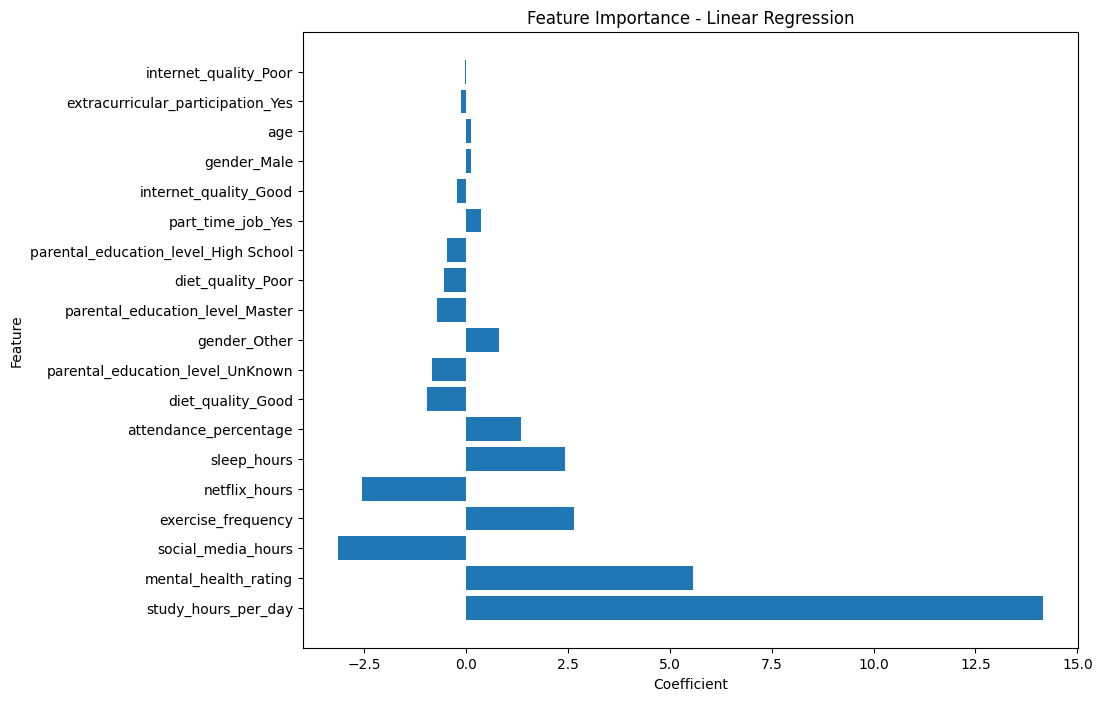

In [203]:
plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Coefficient']
)

plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Feature Importance - Linear Regression')

plt.show()

### Feature Importance Results

The feature coefficients from the Linear Regression model were analyzed to understand the influence of each feature on the predicted exam scores.

* `study_hours_per_day` had the largest positive coefficient, indicating a strong positive relationship with predicted exam scores.
* `mental_health_rating`, `exercise_frequency`, `sleep_hours`, and `attendance_percentage` also had positive coefficients.
* `social_media_hours` and `netflix_hours` had negative coefficients, indicating a negative relationship with predicted exam scores.
* The remaining features had relatively smaller coefficients and therefore had less influence on the model's predictions.

Overall, the model identified study time as the strongest feature, while several lifestyle and academic-related features also contributed to the predictions.


## 12. Save Model and Scaler

The final Linear Regression model and the fitted StandardScaler were saved using Joblib.

* The model is saved to make predictions on new data.
* The scaler is saved because the model was trained on scaled numerical features.
* The same fitted scaler must be used to transform new data before making predictions.


In [209]:
import joblib

In [210]:
joblib.dump(linear,'student_exam_score_model.pkl')


['student_exam_score_model.pkl']

In [211]:
joblib.dump(scaler , 'student_exam_score_scaler.pkl')

['student_exam_score_scaler.pkl']